### l2 regularization 
### l1 regularization

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [25]:
X,y = make_moons(100,noise=0.25,random_state=2)

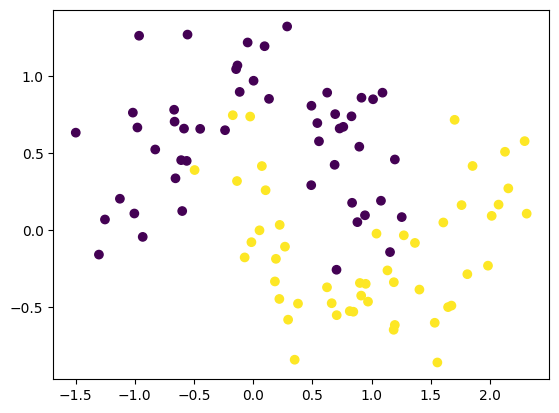

In [26]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y)
plt.show()

In [27]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2,activation="relu"))
model1.add(Dense(128,activation="relu"))
model1.add(Dense(1,activation="sigmoid"))

model1.summary()

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

history1 = model1.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 784us/step


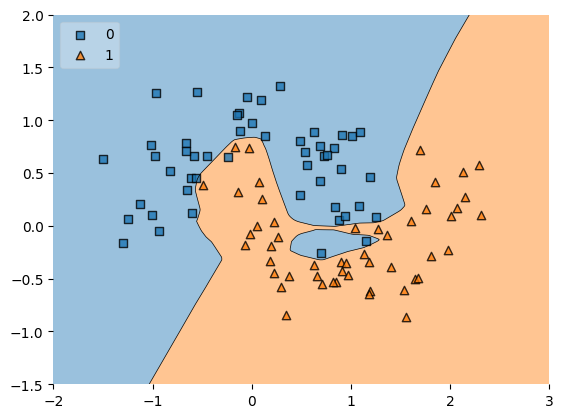

In [14]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

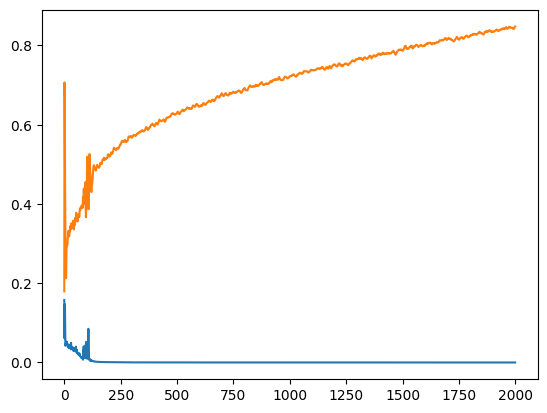

In [17]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [30]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model2.add(Dense(128,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model2.add(Dense(1,activation="sigmoid"))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
adam = Adam(learning_rate=0.01)

model2.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

history2 = model2.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 819us/step


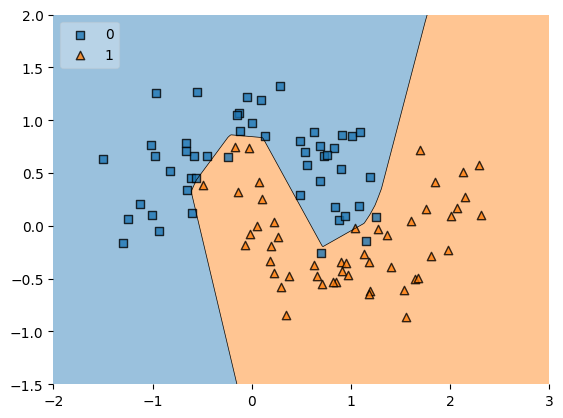

In [32]:
plot_decision_regions(X,y.astype('int'),clf=model2,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

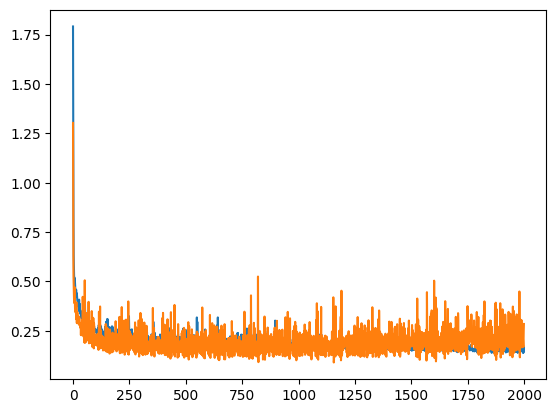

In [33]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [34]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

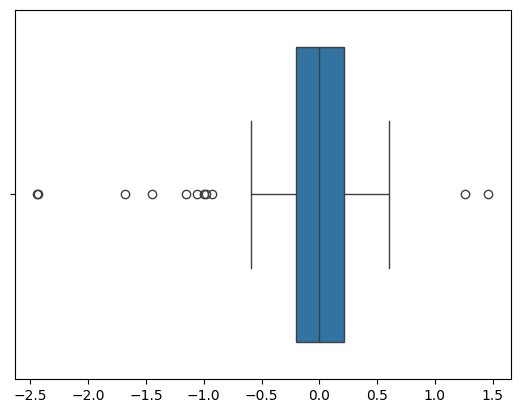

In [37]:
sns.boxplot(x=model1_weight_layer1)

<Axes: >

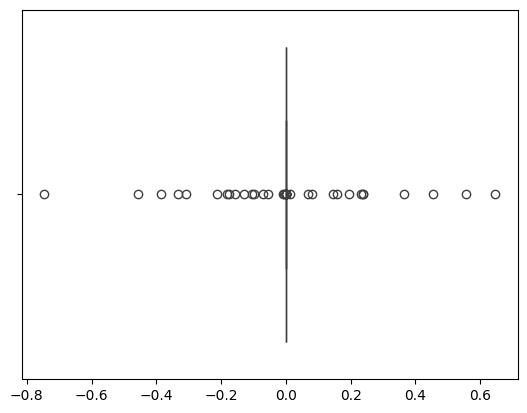

In [39]:
sns.boxplot(x=model2_weight_layer1)

In [40]:
model1_weight_layer1.min()

np.float32(-2.4393797)

In [41]:
model2_weight_layer1.min()

np.float32(-0.74581367)

C:\Users\Durgesh Kumar\AppData\Local\Temp\ipykernel_14376\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\Durgesh Kumar\AppData\Local\Temp\ipykernel_14376\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

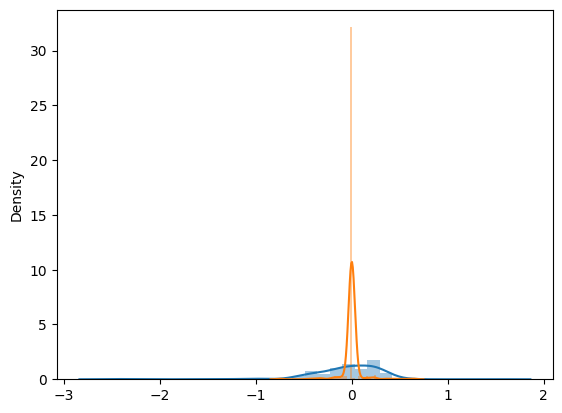

In [42]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [43]:
model1.get_weights()[0].reshape(256)

array([-3.58482497e-03,  1.30726516e-01,  2.86365628e-01,  2.61764675e-01,
        2.48524651e-01, -3.84043157e-01,  2.78587133e-01,  6.54090270e-02,
       -3.66488874e-01,  6.25049397e-02,  2.82795906e-01,  2.22224101e-01,
        2.23114863e-01, -5.45820951e-01,  5.63406721e-02, -4.24464345e-01,
        1.70043901e-01, -5.51175177e-01,  2.20054790e-01,  1.76374584e-01,
       -4.86783564e-01,  2.69693285e-01, -4.30015266e-01,  3.46868038e-01,
       -1.82753384e-01,  1.46989316e-01,  1.80627614e-01,  1.13984510e-01,
        1.72677249e-01, -1.73858609e-02, -5.44846021e-02, -3.51583540e-01,
        1.21351019e-01,  2.34062970e-01,  2.57793456e-01,  1.33922577e-01,
       -6.72586448e-03, -3.31240296e-01, -2.02097803e-01, -2.37410516e-02,
       -2.32847914e-01, -4.90648568e-01,  1.98152527e-01, -8.92879292e-02,
       -5.32897890e-01, -2.54083276e-01,  6.51568919e-02, -4.06614542e-01,
       -3.17351893e-02, -5.01525521e-01, -3.06659281e-01, -3.61834288e-01,
        2.44329348e-01, -